### Testen mit der Binomialverteilung

[Video](https://youtu.be/39Yay9C6vok)

In den meisten Fällen bietet das Bild von der Gerichtsverhandlung einen Hinweis darauf, was als H0-Hypothese zu betrachten ist und was für eine Art von Test durchzuführen ist.

Die H0-Hypothese ist der Angeklagte. Der Angeklagte gilt als unschuldig, solange es dem Staatsanwalt nicht gelingt, dem Gericht signifikante Beweise für seine Schuld vorzulegen. Die H0-Hypothese gilt als akzeptiert, solange der Test nicht zeigt, dass es eine signifikante Abweichung gibt.

Der Richter muss entscheiden, ob eine gegebenenfalls vorliegende Abweichung des Testergebnisses von dem, was H0 behauptet, so signifikant ist, dass H0 verurteilt werden kann (abgelehnt wird). Je kleiner das Signifikanzniveau gewählt wird, desto kleiner wird der Ablehnungsbereich, d.h. desto großzügiger akzeptiert der Richter Abweichungen. Je kleiner das Signifikanzniveau, desto kleiner die Wahrscheinlichkeit, dass der Richter H0 zu unrecht verurteilt.


<img src='test1.png' width='852'>

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import binom

#### Rechtsseitiger Test

In [2]:
'''
Ein Großhandelsshop verkauft eine neue Sorte Saatgut. Der Leiter behauptet, dass unter normalen Bedingungen mehr
als 85% der Samen keimen. Dies möchte er durch einen Test untermauern. Die Nullhypothese "Es keimen höchstens 85% der Samen" 
wird mit einem Stichprobenumfang von 500 Samenkörnern und dem Signifikanzniveau alpha = 5% getestet
a. Bestimmen Sie den Ablehnungsbereich und formulieren Sie die Entscheidungsregel
b. Geben Sie die Irrtumswahrscheinlichkeit an
'''
n = 500
p = 0.85
X = binom(n,p)
alpha = 0.05

# kleinstes k, mit 1-P(X<=k-1) <= alpha
k = n        # Falls alles angenommen wird
while 1-X.cdf(k-1) <= alpha:
    k -= 1   
k_crit = k+1         # das letzte -1 muss wieder zurückgenommen werden

print(f"Ablehnungsbereich: {k_crit}...{n}")

Ablehnungsbereich: 439...500


Entscheidungsregel: Falls mehr als 439 Samenkörner keimen gilt das als Bestätigung der Behauptung, dass normalerweise mehr als 85% der Samen keimen.

Die Wahrscheinlichkeit, dass H0 zutrifft und doch richtig ist: der Fehler 1. Art

In [3]:
f1 = 1-X.cdf(k_crit-1)
print(f"Irrtumswahrscheinlichkeit: {f1:.3f}")

Irrtumswahrscheinlichkeit: 0.043


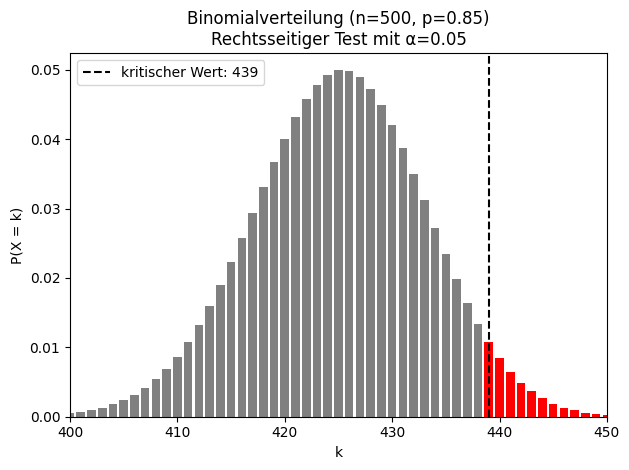

In [8]:
# Visualisierung
xx = np.arange(n + 1)
yy = X.pmf(xx)

# Farbe: rot im Ablehnungsbereich, grau sonst
colors = ['red' if x >= k_crit else 'gray' for x in xx]

plt.bar(xx, yy, color=colors)
plt.axvline(k_crit, color='black', linestyle='--', label=f'kritischer Wert: {k_crit}')
plt.title(f'Binomialverteilung (n={n}, p={p})\nRechtsseitiger Test mit α={alpha}')
plt.xlabel('k')
plt.xlim(400,450)
plt.ylabel('P(X = k)')
plt.legend()
plt.tight_layout()
plt.show()

#### Linksseitiger Test

In [9]:
'''
Bei der Produktion von elektronischen Bauteilen beträgt der Anteil defekter Teile erfahrungsgemäß 8%.
Nach Veränderungen im Produktionsprozess vermutet man, dass sich dieser Anteil verringert hat. 
Dazu wird eine Stichprobe von 200 Teilen entnommen. 
Formuliere eine Entscheidungsregel mit Signifikanzniveau 0.05 und bestimme die Irrtumswahrscheinlichkeit.
'''

n = 200
p = 0.08
X = binom(n,p)
alpha = 0.05
k = 0
# größtes k mit P(X<=k) <= alpha:
while X.cdf(k) <= alpha:
    k+=1
k_crit = k-1
print(f'Ablehnungsbereich: 0...{k_crit}')

Ablehnungsbereich: 0...9


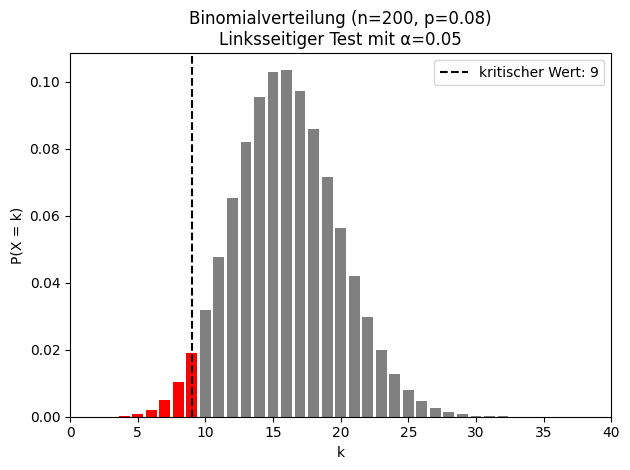

In [12]:
# Visualisierung
xx = np.arange(n + 1)
yy = X.pmf(xx)

# Farbe: rot im Ablehnungsbereich, grau sonst
colors = ['red' if x <= k_crit else 'gray' for x in xx]

plt.bar(xx, yy, color=colors)
plt.axvline(k_crit, color='black', linestyle='--', label=f'kritischer Wert: {k_crit}')
plt.title(f'Binomialverteilung (n={n}, p={p})\nLinksseitiger Test mit α={alpha}')
plt.xlabel('k')
plt.ylabel('P(X = k)')
plt.xlim(0,40)
plt.legend()
plt.tight_layout()
plt.show()

In [13]:
'''
Alexandra hat ein Glücksrad gebaut. Yannik behauptet, die Gewinnwahrscheinlichkeit sei kleiner als 25%. 
Formuliere einen Test mit Stichprobenumfang 60 mit Signifikanzniveau 5%, bestimme den Ablehungsbereich und formuliere eine Entscheidungsregel
'''
n = 60
p = 0.25
X = binom(n,p)
alpha = 0.05
k = 0
while X.cdf(k) <= alpha:
    k+=1
k_crit = k-1
print(f'Ablehnungsbereich: 0...{k_crit}')

Ablehnungsbereich: 0...9


Entscheidungsregel: Wenn nur 0..9 Gewinne auftreten, wird Yanniks Behauptung akzeptiert.

#### Fehler der 1. und 2. Art

<img src='test2.png' width='900'>



In [14]:
'''
Ein Handwärmer erhitzt sich nach Klicken eines Metallplättchens. Wird er nach Gebrauch
in kochendes Wasser gelegt, kann er erneut verwendet werden. Funktioniert dies mindestens
40-mal, so gilt der Handwärmer als voll funktionsfähig. Bei der Herstellerfirma soll ein Test
mit der Nullhypothese "Höchstens 80% der Handwärmer sind voll funktionsfähig" mit einem
Stichprobenumfang von 150 und Signifikanzniveau 5% durchgeführt werden.
a. Bestimme die Wahrscheinlichkeit des Fehlers 1.Art
b. Berechne die Wahrscheinlichkeit des Fehlers 2.Art, wenn sogar tatsächlich 90% der Handwärmer voll funktionsfähig sind.
'''
n = 150
p = 0.8
X = binom(n,p)
alpha = 0.05
# Test rechts
k = n+1
while 1-X.cdf(k-1) <= alpha:
    k-=1
k_crit = k+1
print(f'Ablehnungsbereich {k_crit}...n')

Ablehnungsbereich 129...n


In [15]:
# Wahrscheinlichkeit für Fehler 1. Art
f1 = 1-X.cdf(k_crit-1)
print(f'Wahrscheinlichkeit für Fehler 1. Art {f1:.3f}')

Wahrscheinlichkeit für Fehler 1. Art 0.037


In [16]:
# Wahrscheinlichkeit für Fehler 2. Art
p1 = 0.9    # p1 = die Wahrheit
X1 = binom(n,p1)
f2 = X1.cdf(k_crit-1)
print(f'Wahrscheinlichkeit für Fehler 2. Art {f2:.3f}') 

Wahrscheinlichkeit für Fehler 2. Art 0.044


In [19]:
'''
Ein Landwirt bezieht Rapssamen von einem Großhändler. Dieser gibt an, dass deren Keimfähigkeit mindestens 85% betrage.
Der Landwirt zweifelt daran und möchte 200 Rapssamen untersuchen. Er wählt die Entscheidungsregel: Wenn höchstens
160 Rapssamen keimen, gehe ich davon aus, dass die Keimfähigkeit unter 85% liegt, und reklamiere die Lieferung.
a. Bestimme die Wahrscheinlichkeit des Fehlers 1. Art
b. In Wirklichkeit ist die Keimfähigkeit der Samen nur 80%. Bestimme die Wahrscheinlichkeit des Fehlers zweiter Art.
c  Bestimme die Wahrscheinlichkeit des Fehlers zweiter Art, wenn die Keimfähigkeit nur 75% beträgt.
'''
n = 200
p = 0.85
# Test links
X = binom(n,p)
f1 = X.cdf(160)
print(f'a. Wahrscheinlichkeit für Fehler 1. Art {f1:.3f}') 

p1 = 0.80
X1 = binom(n,p1)
f2 = 1-X1.cdf(160)
print(f'b. Wahrscheinlichkeit für Fehler 2. Art {f2:.3f}') 

p1 = 0.75
X1 = binom(n,p1)
f2 = 1-X1.cdf(160)
print(f'c. Wahrscheinlichkeit für Fehler 2. Art {f2:.3f}') 

a. Wahrscheinlichkeit für Fehler 1. Art 0.034
b. Wahrscheinlichkeit für Fehler 2. Art 0.472
c. Wahrscheinlichkeit für Fehler 2. Art 0.041


#### Zweiseitiger Hypothesentest

Der Ablehnungsbereich wird links und rechts mit einem Signifikanzniveau von alpha/2 berechnet.

<img src='test3.png' width='850'>

In [21]:
'''
Beträgt die Wahrscheinlichkeit eine 6 bei einem Würfel zu Würfeln wirklich 1/6? 
Wir testen 100 mal
'''
n = 100
p = 1/6
X = binom(n,p)
alpha = 0.05

k = 0
while X.cdf(k) <= alpha/2:
    k+=1
k_links = k-1
print(f'Ablehnungsbereich links 0...{k_links}')

k = n+1
while 1-X.cdf(k-1) <= alpha/2:
    k-=1
k_rechts = k+1
print(f'Ablehnungsbereich rechts {k_rechts}..{n}')


Ablehnungsbereich links 0...9
Ablehnungsbereich rechts 25..100


In [75]:
'''
Bei einem Glücksspielautomaten soll mit einer Wahrscheinlichkeit von 15% die
Kombination '3-mal Goldmünze' erscheinen. Dies soll durch einen Test mit einem
Stichprobenumfang von 100 mit Signifikanzniveau 5% überprüft werden.
a. Gib die Wahrscheinlichkeit für einen Fehler der 1. Art an
b. Gib die Wahrscheinlichkeit für einen Fehler der 2. Art an, wenn die Kombination
tatsächlich mit einer Wahrscheinlichkeit von 10% erscheint.
'''
n = 100
p = 0.15
X = binom(n,p)
alpha = 0.05

k = 0
while X.cdf(k) <= alpha/2:
    k+=1
k_links = k-1
print(f'Ablehnungsbereich links: 0...{k_links}')

k = n+1
while 1-X.cdf(k-1) <= alpha/2:
    k-=1
k_rechts = k+1
print(f'Ablehnungsbereich rechts: {k_rechts}..{n}')

Ablehnungsbereich links: 0...7
Ablehnungsbereich rechts: 23..100


In [76]:
# Fehler 1. Art
f1 = X.cdf(k_links) + 1-X.cdf(k_rechts-1)
print(f'Fehler 1. Art: {f1:.3f}')

Fehler 1. Art: 0.034


In [77]:
# Fehler 2. Art
p1 = 0.1
X1 = binom(n,p1)
f2 = X1.cdf(k_rechts-1) - X1.cdf(k_links)
print(f'Fehler 2. Art: {f2:.3f}')

Fehler 2. Art: 0.794


#### Funktionen

Wir definieren uns Funktionen, die uns die Ablehnungsbereiche und den Fehler 1.Art zurückgeben. Falls uns p_wahr mitgegeben wird, können wir auch den Fehler der 2. Art berechnen.

In [84]:
def links_test(n,p,alpha=0.05, p_wahr=None):
    X = binom(n,p)
    k = 0
    while X.cdf(k) <= alpha:
        k+=1
    k_crit = k-1
    res = f'Ablehnungsbereich links: 0...{k_crit}, Irrtumswahrscheinlichkeit: {X.cdf(k_crit):.3f}'
    if p_wahr:
        if p_wahr >= p:
            res += ', H0 ist wahr'
        else:
            X1 = binom(n,p_wahr)
            res += f', Fehler 2.Art: {1-X1.cdf(k_crit):.3f}'
    return res

print(links_test(200,0.1,p_wahr=0.08))

Ablehnungsbereich links: 0...12, Irrtumswahrscheinlichkeit: 0.032, Fehler 2.Art: 0.818


In [85]:
def rechts_test(n,p,alpha=0.05,p_wahr=None):
    X = binom(n,p)
    k = n
    while 1-X.cdf(k-1) <= alpha:
        k-=1
    k_crit = k+1
    res = f'Ablehnungsbereich rechts: {k_crit}...{n}, Irrtumswahrscheinlichkeit: {1-X.cdf(k_crit-1):.3f}'
    if p_wahr:
        if p_wahr <= p:
            res += ', H0 ist wahr'
        else:
            X1 = binom(n,p_wahr)
            res += f', Fehler 2.Art: {X1.cdf(k_crit-1):.3f}'
    return res

print(rechts_test(150,0.8,p_wahr=0.9))

Ablehnungsbereich rechts: 129...150, Irrtumswahrscheinlichkeit: 0.037, Fehler 2.Art: 0.044


In [86]:
def zweiseitig_test(n,p,alpha=0.05, p_wahr=None):
    X = binom(n,p)
    k = 0
    while X.cdf(k) <= alpha/2:
        k+=1
    k_links = k-1
    ablehnung_links = f'0...{k_links}'
    irrtum_links = X.cdf(k_links)

    k = n
    while 1-X.cdf(k-1) <= alpha/2:
        k-=1
    k_rechts = k+1
    ablehnung_rechts = f'{k_rechts}...{n}'
    irrtum_rechts = 1-X.cdf(k_rechts-1)

    res = f'Ablehnungsbereiche {ablehnung_links} und {ablehnung_rechts}, Irrtumswahrscheinlichkeit {irrtum_links+irrtum_rechts:.3f}'
    if p_wahr:
        if p_wahr == p:
             res += ', H0 ist wahr'
        else:
             res += f', Fehler 2.Art: {X1.cdf(k_rechts-1) - X1.cdf(k_links):.3f}'
    return res

zweiseitig_test(100,0.15,p_wahr=0.1)

'Ablehnungsbereiche 0...7 und 23...100, Irrtumswahrscheinlichkeit 0.034, Fehler 2.Art: 0.794'

#### Bleistifte

In [87]:
print(rechts_test(800,0.02,p_wahr=0.025))

Ablehnungsbereich rechts: 24...800, Irrtumswahrscheinlichkeit: 0.035, Fehler 2.Art: 0.790


#### Weizen

In [90]:
print(links_test(500,0.80,alpha=0.1))

Ablehnungsbereich links: 0...387, Irrtumswahrscheinlichkeit: 0.083


In [91]:
X = binom(500,0.82)
X.cdf(387)

np.float64(0.005319282077786117)

In [ ]:
n = 200
p = 0.08
X = binom(n,p)
alpha = 0.05
k = 0
# größtes k mit P(X<=k) <= alpha:
while X.cdf(k) <= alpha:
    k+=1
k_crit = k-1
print(f'Ablehnungsbereich: 0...{k_crit}')

In [29]:
from sympy import symbols
from sympy import solve_univariate_inequality   
from sympy.stats import Binomial, P
n = 200 
p = 0.08
alpha = 0.05
k = symbols('k')
X = Binomial('X', n, p)
ug = P(X <= k) < alpha
solve_univariate_inequality(ug,k)

KeyboardInterrupt: 